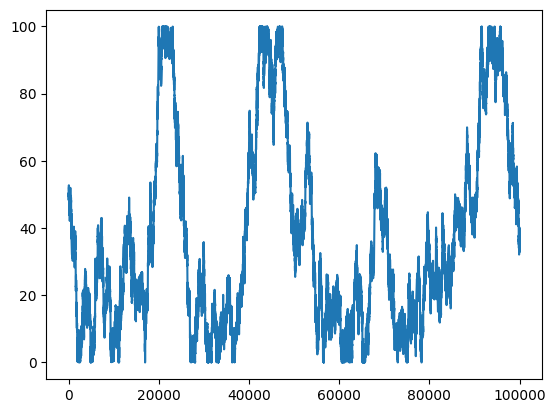

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from numpy.typing import NDArray


def reflect_into_interval(
    x: NDArray[np.floating], lower_bound: float, upper_bound: float
) -> NDArray[np.floating]:
    """Reflect values into interval [lower_bound, upper_bound] using triangle wave method.

    This implements reflecting boundary conditions for random walks by treating
    the walk as a triangle wave that bounces off the boundaries.

    Parameters
    ----------
    x : np.ndarray
        Array of values to reflect.
    lower_bound : float
        Lower bound of interval.
    upper_bound : float
        Upper bound of interval.

    Returns
    -------
    reflected : np.ndarray
        Array of same shape as x with all values in [lower_bound, upper_bound].

    Examples
    --------
    Reflect values outside bounds:

    >>> x = np.array([-1.0, 0.5, 2.5])
    >>> result = reflect_into_interval(x, 0.0, 2.0)
    >>> (result >= 0.0).all() and (result <= 2.0).all()
    True

    Values inside bounds are unchanged:

    >>> x = np.array([0.5, 1.0, 1.5])
    >>> result = reflect_into_interval(x, 0.0, 2.0)
    >>> np.allclose(result, x)
    True
    """
    interval_length = upper_bound - lower_bound
    y: NDArray[np.floating] = np.mod(x - lower_bound, 2 * interval_length)
    y = np.where(y <= interval_length, y, 2 * interval_length - y)
    result: NDArray[np.floating] = y + lower_bound
    return result


def simulate_walk(
    n_time: int,
    sig: float,
    x0: float,
    xs_min: float,
    xs_max: float,
    rng: np.random.Generator,
) -> NDArray[np.floating]:
    """Simulate random walk with reflecting boundary conditions.

    Simulates a Gaussian random walk on continuous space with reflecting
    boundaries. The walk starts at x0 and takes steps drawn from a Gaussian
    distribution with standard deviation sig.

    Parameters
    ----------
    n_time : int
        Number of time steps to simulate.
    sig : float
        Standard deviation of step size distribution.
    x0 : float
        Initial position.
    xs_min : float
        Lower boundary (reflecting).
    xs_max : float
        Upper boundary (reflecting).
    rng : np.random.Generator
        Random number generator for reproducibility.

    Returns
    -------
    trajectory : np.ndarray, shape (n_time,)
        Simulated trajectory with all values in [xs_min, xs_max].

    Examples
    --------
    Simulate a 100-step random walk:

    >>> rng = np.random.default_rng(42)
    >>> walk = simulate_walk(100, sig=1.0, x0=50.0, xs_min=0.0, xs_max=100.0, rng=rng)
    >>> walk.shape
    (100,)
    >>> (walk >= 0.0).all() and (walk <= 100.0).all()
    True

    With zero step size, trajectory is constant:

    >>> rng = np.random.default_rng(42)
    >>> walk = simulate_walk(10, sig=0.0, x0=50.0, xs_min=0.0, xs_max=100.0, rng=rng)
    >>> np.allclose(walk, 50.0)
    True
    """
    steps = rng.normal(loc=0.0, scale=sig, size=n_time)
    x = x0 + np.cumsum(steps)
    return reflect_into_interval(x, xs_min, xs_max)


# Example usage
position_min = 0.0
position_max = 100.0
position_std = 0.5
n_timesteps = 100_000
position_start = 50.0
position = simulate_walk(
    n_timesteps,
    sig=position_std,
    x0=position_start,
    xs_min=position_min,
    xs_max=position_max,
    rng=np.random.default_rng(42),
)

plt.plot(position)

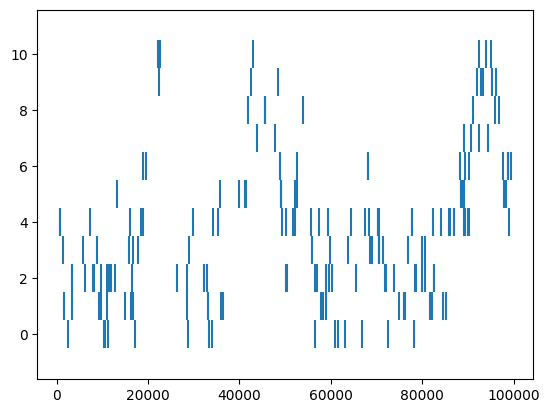

In [ ]:
from scipy.stats import norm


def get_place_field_centers(
    position_min=0.0,
    position_max=100.0,
    place_field_spacing: float = 10.0,
) -> NDArray[np.floating]:
    n_neurons = int((position_max - position_min) / place_field_spacing) + 1
    place_field_centers = np.linspace(position_min, position_max, n_neurons)
    return place_field_centers


def generate_spike_trains(
    position: NDArray[np.floating],
    place_field_centers: NDArray[np.floating],
    place_field_width: float = 10.0,
    scale: float = 0.02,
    rng=None,
):
    if rng is None:
        rng = np.random.default_rng()

    rv = norm(loc=place_field_centers[:, np.newaxis], scale=place_field_width)
    spike_rate = rv.pdf(position).T * scale  # spikes / bin
    return rng.poisson(spike_rate)


place_field_centers = get_place_field_centers()
spike_count = generate_spike_trains(
    position,
    place_field_centers,
    place_field_width=10.0,
)
spike_time_ind, spike_neuron_ind = np.nonzero(spike_count)
# Organize spike times by neuron for eventplot
spike_times_by_neuron = [
    spike_time_ind[spike_neuron_ind == i] for i in range(len(place_field_centers))
]
plt.eventplot(spike_times_by_neuron)

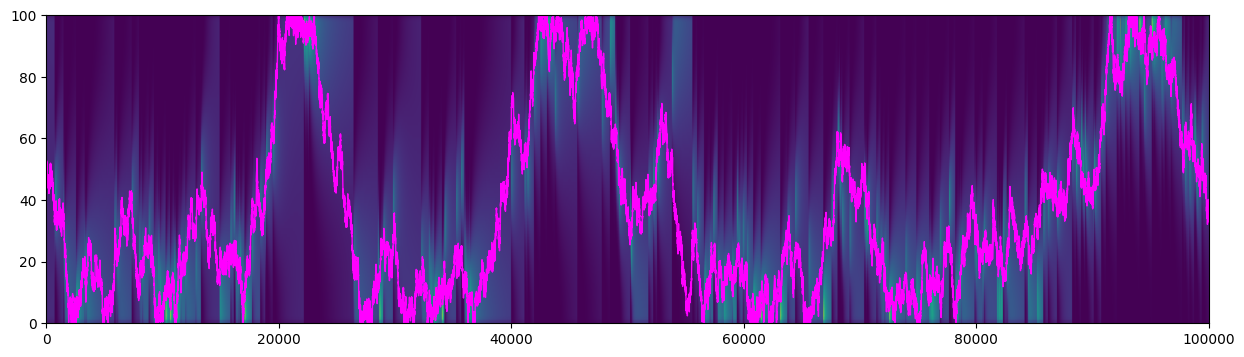

In [51]:
import scipy.stats


def compute_likelihood(
    spike_counts_t: NDArray[np.floating],
    place_fields: NDArray[np.floating],
) -> NDArray[np.floating]:
    likelihood = np.prod(
        scipy.stats.poisson.pmf(k=spike_counts_t[:, np.newaxis], mu=place_fields.T),
        axis=0,
    )

    return likelihood


def make_random_walk_transition_matrix(
    position_bins: NDArray[np.floating],
    movement_mean: float = 0.0,
    movement_var: float = 1.0,
) -> NDArray[np.floating]:
    transition_matrix = np.stack(
        [
            scipy.stats.multivariate_normal(mean=center + movement_mean, cov=movement_var).pdf(
                position_bins
            )
            for center in position_bins
        ],
        axis=1,
    )
    transition_matrix /= transition_matrix.sum(axis=1, keepdims=True)  # Normalize rows
    return transition_matrix


def run_decoder(spike_count, place_fields, position_bins, rw_std: float = 1.0):
    n_position_bins = position_bins.shape[0]
    initial_conditions = np.ones(n_position_bins) / n_position_bins  # Uniform prior
    transition_matrix = make_random_walk_transition_matrix(position_bins, movement_var=rw_std**2)
    n_time = spike_count.shape[0]
    posterior = np.zeros((n_time, n_position_bins))
    one_step_prediction = np.zeros((n_time, n_position_bins))

    posterior[0] = initial_conditions
    for t in range(1, n_time):
        one_step_prediction[t] = posterior[t - 1] @ transition_matrix
        likelihood = compute_likelihood(spike_count[t], place_fields)
        posterior[t] = one_step_prediction[t] * likelihood
        posterior[t] /= posterior[t].sum()  # Normalize

    return posterior, one_step_prediction


n_position_bins = 100
position_bins = np.linspace(position_min, position_max, n_position_bins)
place_fields = (
    norm.pdf(
        position_bins[:, np.newaxis],
        loc=place_field_centers[np.newaxis, :],
        scale=10.0,
    )
    * 0.02
)  # spikes / bin

posterior, one_step_prediction = run_decoder(spike_count, place_fields, position_bins)
plt.figure(figsize=(15, 4))
plt.imshow(
    posterior.T,
    aspect="auto",
    origin="lower",
    extent=[0, n_timesteps, position_min, position_max],
)
plt.plot(position, color="magenta", linewidth=1)

In [92]:
summed_rate_over_position = np.sum(place_fields, axis=1, keepdims=True)
neuron_fraction_of_total_rate = (
    place_fields / summed_rate_over_position
)  # Ratio of each neuron's rate to total rate
neuron_fraction_of_total_rate.shape

(100, 11)

In [ ]:
expected_population_share = (
    one_step_prediction @ neuron_fraction_of_total_rate
)  # weighted average of neuron fractions, shape (n_timesteps, n_neurons)
expected_population_share

array([[0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.05986092, 0.0920911 , 0.1000247 , ..., 0.1000247 , 0.0920911 ,
        0.05986092],
       [0.05983806, 0.09211617, 0.10003801, ..., 0.10003801, 0.09211617,
        0.05983806],
       ...,
       [0.0207801 , 0.03995216, 0.06114081, ..., 0.11841091, 0.09575305,
        0.05694922],
       [0.02082165, 0.04000874, 0.06118072, ..., 0.11841762, 0.09580129,
        0.05699474],
       [0.02086316, 0.04006525, 0.06122056, ..., 0.11842431, 0.0958494 ,
        0.05704014]], shape=(100000, 11))

In [128]:
time_ind = 737
is_spike = spike_count[time_ind] > 0
expected_population_share_sorted = np.sort(expected_population_share, axis=1)
cdf_sorted = np.cumsum(expected_population_share_sorted, axis=1)
counts = (
    expected_population_share_sorted[:, None, :] <= expected_population_share[:, :, None]
).sum(axis=2)
spike_prob = np.take_along_axis(cdf_sorted, counts - 1, axis=1)
spike_prob = np.where(spike_count > 0, spike_prob, np.nan)
spike_prob

array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]], shape=(100000, 11))

In [130]:
spike_prob[737]

array([       nan,        nan,        nan,        nan, 0.60094942,
              nan,        nan,        nan,        nan,        nan,
              nan])

(array([ 4.,  1.,  2.,  3.,  5.,  4.,  4.,  4.,  5.,  7.,  6.,  3.,  5.,
         7.,  8.,  8.,  3.,  3.,  3.,  8.,  9., 10.,  9.,  5.,  7.,  5.,
         0.,  0.,  0., 44.]),
 array([0.0733372 , 0.10422596, 0.13511472, 0.16600348, 0.19689224,
        0.227781  , 0.25866976, 0.28955852, 0.32044728, 0.35133604,
        0.3822248 , 0.41311356, 0.44400232, 0.47489108, 0.50577984,
        0.5366686 , 0.56755736, 0.59844612, 0.62933488, 0.66022364,
        0.6911124 , 0.72200116, 0.75288992, 0.78377868, 0.81466744,
        0.8455562 , 0.87644496, 0.90733372, 0.93822248, 0.96911124,
        1.        ]),
 <BarContainer object of 30 artists>)

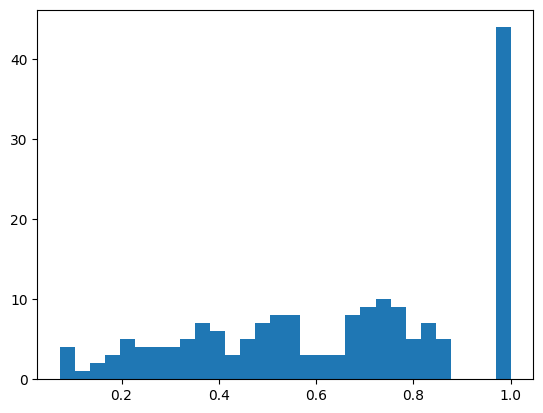

In [131]:
plt.hist(spike_prob[~np.isnan(spike_prob)], bins=30)

In [102]:
one_step_prediction.shape, neuron_fraction_of_total_rate.shape, expected_rate.shape

((100000, 100), (100, 11), (11,))

In [98]:
expected_rate.shape

(100, 11)

<BarContainer object of 11 artists>

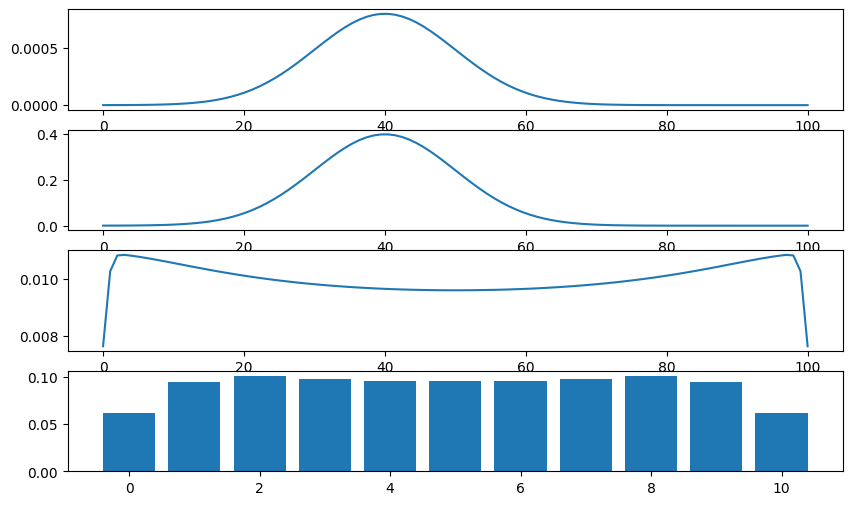

In [107]:
fig, axes = plt.subplots(4, 1, figsize=(10, 6))

axes[0].plot(position_bins, place_fields[:, is_spike].squeeze())
axes[1].plot(position_bins, neuron_fraction_of_total_rate[:, is_spike].squeeze())
axes[2].plot(position_bins, one_step_prediction[time_ind])
axes[3].bar(
    np.arange(expected_rate.shape[0]),
    expected_rate,
)